# **OCR Example using VLM called `GOT-OCR-2.0`**

In this notebook te objective is show as we can use a VLM as OCR engine to read characters from an image. This notebook is only for academic purposes.

To execute this notebook, create a virtual environment only for this task. On this way, we don't mix our project work environment.

The VLM used in this notebook called [GOT-OCR 2.0](https://huggingface.co/stepfun-ai/GOT-OCR2_0)

## **Install dependencies**

In [1]:
!pip install torch torchvision transformers==4.37.2 tiktoken verovio accelerate==0.30.0 matplotlib pillow

## **Libraries**

In [24]:
from transformers import AutoModel, AutoTokenizer
from PIL import Image
import transformers
import matplotlib.pyplot as plt

print(f"Transformers version: {transformers.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"PIL version: {Image.__version__}")

Transformers version: 4.37.2
Matplotlib version: 3.10.0
PIL version: 11.3.0


In [3]:
tokenizer = AutoTokenizer.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True)
model = AutoModel.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True, low_cpu_mem_usage=True, device_map='cuda', use_safetensors=True, pad_token_id=tokenizer.eos_token_id)
model = model.eval().cuda()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

tokenization_qwen.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ucaslcl/GOT-OCR2_0:
- tokenization_qwen.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


qwen.tiktoken: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/ucaslcl/GOT-OCR2_0:
- render_tools.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


got_vision_b.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ucaslcl/GOT-OCR2_0:
- got_vision_b.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/ucaslcl/GOT-OCR2_0:
- render_tools.py
- got_vision_b.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/root/.cache/huggingface/modules/transformers_modules/ucaslcl/GOT-OCR2_0/979938bf89ccdc949c0131ddd3841e24578a4742/modeling_GOT.py:623: SyntaxWarning: invalid escape sequence '\l'
  left_num = outputs.count('\left')
/root/.cache/huggingface/modules/transformers_modules/ucaslcl/GOT-OCR2_0/979938bf89ccdc949c0131ddd3841e24578a4742/modeling_GOT.py:626: SyntaxWarning: invalid escape sequence '\l'
  outputs = outputs.replace('\left(', '(').replace('

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

In [18]:
def inference(model, image_fil, ocr_type='ocr'):
  """Read text from image using a VLM called GOT-OCR2.0"""
  res = model.chat(tokenizer, image_file, ocr_type=ocr_type)
  return res

def show_image(image_file, title):
  img = Image.open(image_file)
  plt.imshow(img)
  plt.title(title)
  plt.show()

### **Document Number examples**

In this case, make the inference on some `document number` image.

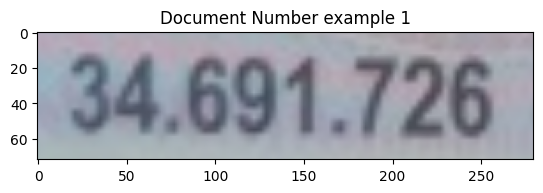

In [20]:
image_file = "./1004_0.png"
show_image(image_file, "Document Number example 1")

In [18]:
print(f"GOT-OCR2_0 response: {inference(model, image_file)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: 34691726


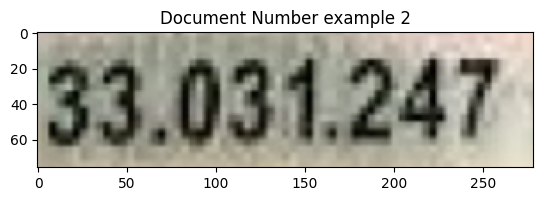

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: 33.031.247


In [21]:
image_file = "./0995_0.png"

show_image(image_file, "Document Number example 2")
print(f"GOT-OCR2_0 response: {inference(model, image_file)}")

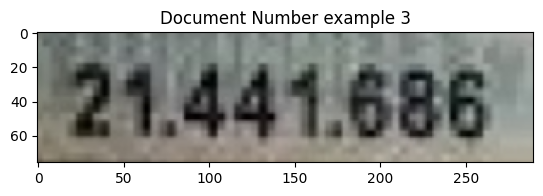

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: 21.441.686


In [21]:
image_file = "./0986_0.png"

show_image(image_file, "Document Number example 3")
print(f"GOT-OCR2_0 response: {inference(model, image_file)}")

### **Tramite Number examples**

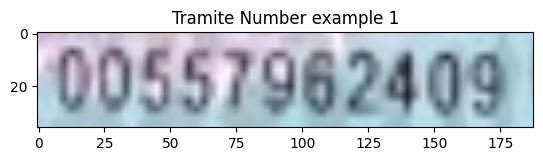

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: 00557962409


In [8]:
image_file = "./3020_0.png"

show_image(image_file, "Tramite Number example 1")
print(f"GOT-OCR2_0 response: {inference(model, image_file)}")

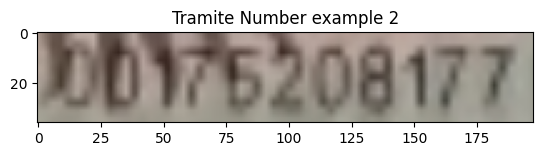

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: 00175208177


In [5]:
image_file = "./3008_0.png"

show_image(image_file, "Tramite Number example 2")
print(f"GOT-OCR2_0 response: {inference(model, image_file)}")

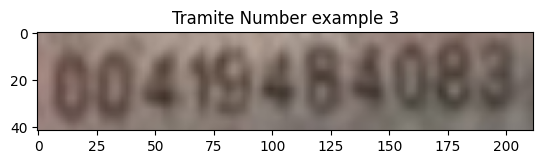

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: 00419484083


In [7]:
image_file = "./1069_0.png"

show_image(image_file, "Tramite Number example 3")
print(f"GOT-OCR2_0 response: {inference(model, image_file)}")

### **MRZ**

###

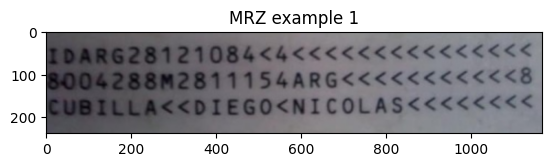

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: \begin{tabular}{lll} 
IDAR G28121084<4<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< \\
8004288M2811154AR G<<<<<<<<<<<<<<<<<<<<8 \\
CUBILLA<<DIEGO<NICOLAS<<<<<<<<<<<
\end{tabular}


In [19]:
image_file = "./1096_0.png"

show_image(image_file, "MRZ example 1")
print(f"GOT-OCR2_0 response: {inference(model, image_file, ocr_type='format')}")

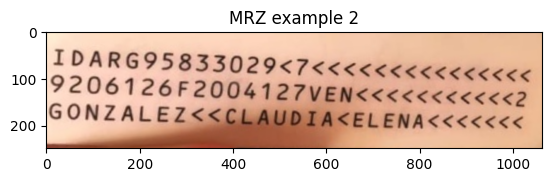

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


GOT-OCR2_0 response: \text{IDARG95833029<7<CCCCC<CCCCC<CCCCC}


In [22]:
image_file = "./1029_0.png"

show_image(image_file, "MRZ example 2")
print(f"GOT-OCR2_0 response: {inference(model, image_file, ocr_type='format')}")